In [ ]:
import time
from pythonosc.udp_client import SimpleUDPClient
import os
import pathlib
import itertools
from music21 import (
    tempo,
    chord,
    note,
    stream,
    meter,
    duration,
    corpus,
    converter,
    serial,
    expressions,
)
import random

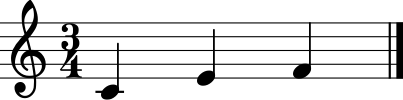

In [26]:
s = stream.Stream()
s.append(meter.TimeSignature("3/4"))
for k in "cef":
    n = note.Note(f"{k.upper()}4")
    s.append(n)
s.show()

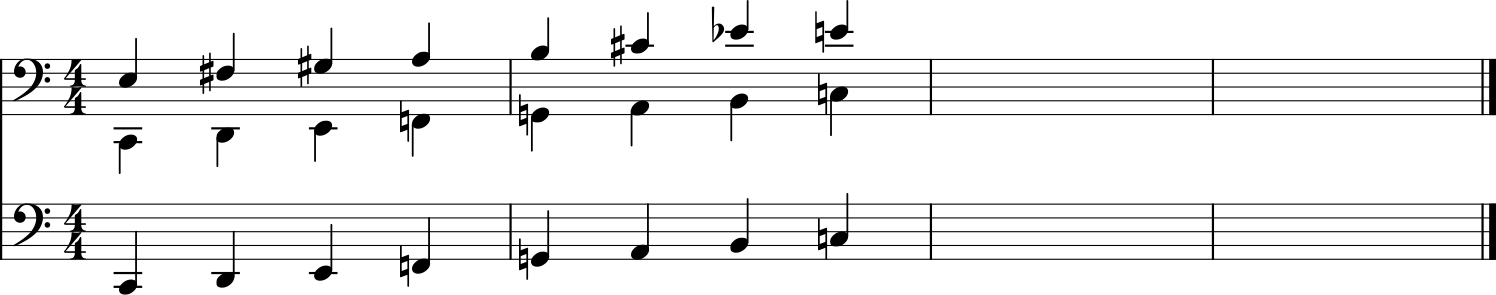

PosixPath('/utkusarioglu-com/workshops/signals-workshop/src/aa.xml')

In [ ]:
# environment.set("musicxmlColor", "white")
score = stream.Score()
piano = stream.Part()
bass = stream.Part()
piano_1 = stream.Voice()
piano_2 = stream.Voice()

notes = ["C4", "D4", "E4", "F4", "G4", "A4", "B4", "C5"]

for n in notes:
    melody_note = note.Note(n)
    piano_2.append(melody_note)
    piano_1.append(melody_note.transpose(-8))

    bass_note = melody_note
    bass_note.octave -= 2
    bass.append(bass_note)

piano.append([piano_1, piano_2])

score.insert(0, piano)
score.insert(0, bass)

score.show()
score.write("musicxml", fp="aa.xml")

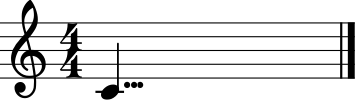

In [34]:
s = stream.Score()
p = stream.Part()
v = stream.Voice()
dur1 = duration.Duration(1.5)
dur2 = duration.Duration(type="quarter", dots=3)
n = note.Note("C4")
n.duration = dur2
v.append(n)
p.append(v)
s.append(p)

s.show()

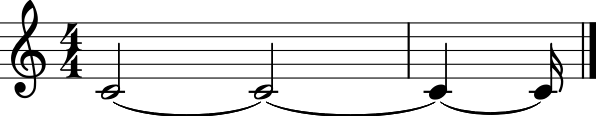

In [39]:
p = stream.Part()
n = note.Note()
d = duration.Duration(5.25)
n.duration = d
n = n.splitAtQuarterLength(2)
p.append(n)
p.show()

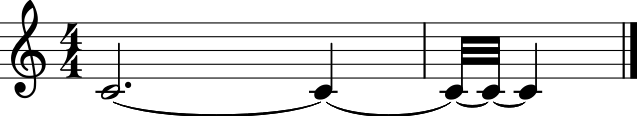

In [ ]:
p = stream.Part()
p.append(
    note.Note("C4", duration=duration.Duration(5.25)).splitByQuarterLengths(
        [3, 1, 0.125, 0.125, 1]
    )
)
p.show()

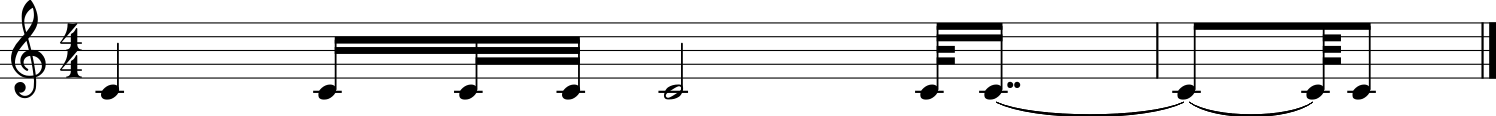

In [ ]:
p = stream.Part()
durs = [1, 1 / 4, 1 / 8, 1 / 8, 2, 1 / 16, 1, 1 / 2]

for dur in durs:
    p.append(note.Note("C4", duration=duration.Duration(dur)))

p.show()

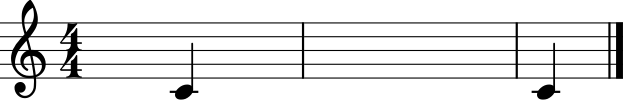

In [50]:
p = stream.Part()

p.insertAndShift(2, note.Note("C4"))
p.insertAndShift(8, note.Note("C4"))
p.show()

In [52]:
corpus.getComposer("Bach")

[PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv1.6.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv10.7.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv101.7.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv102.7.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv103.6.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv104.6.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv108.6.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv11.6.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv110.7.mxl'),
 PosixPath('/opt/conda/envs/music/lib/python3.13/site-packages/music21/corpus/bach/bwv111.6.mxl'),
 PosixPath('/o

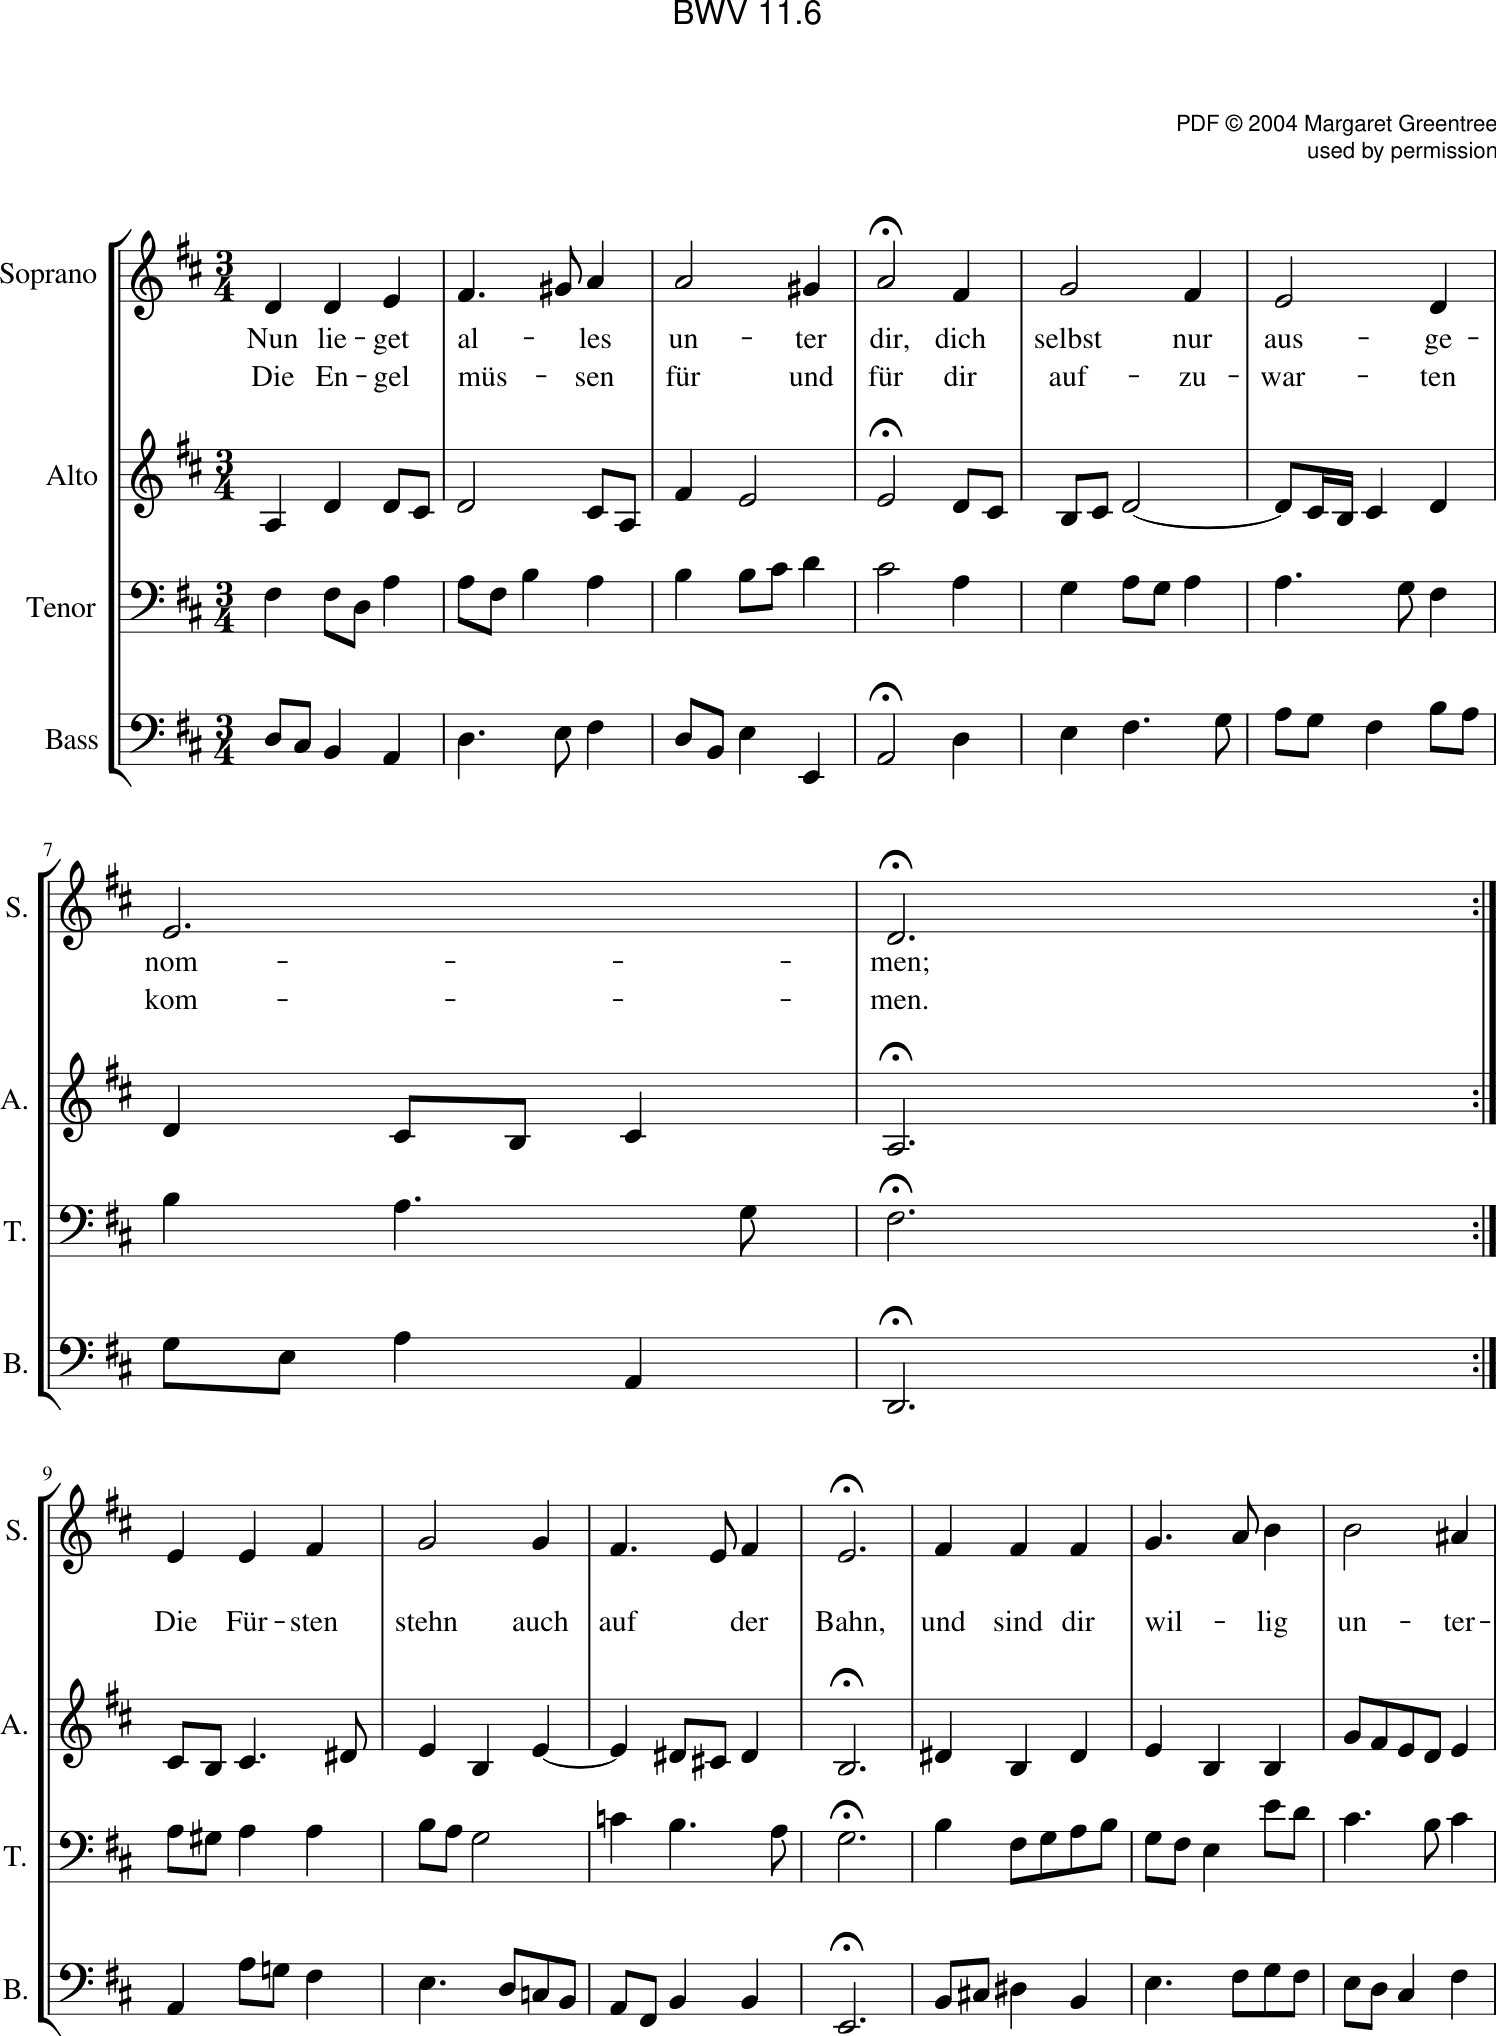

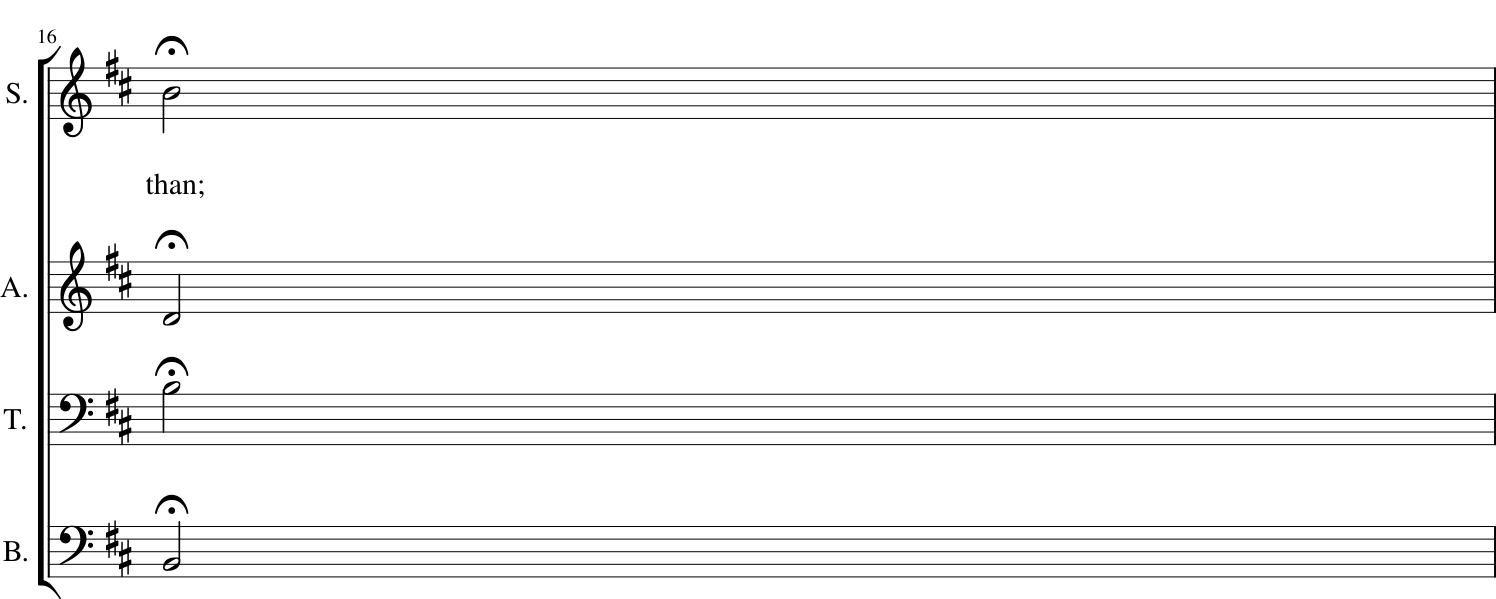

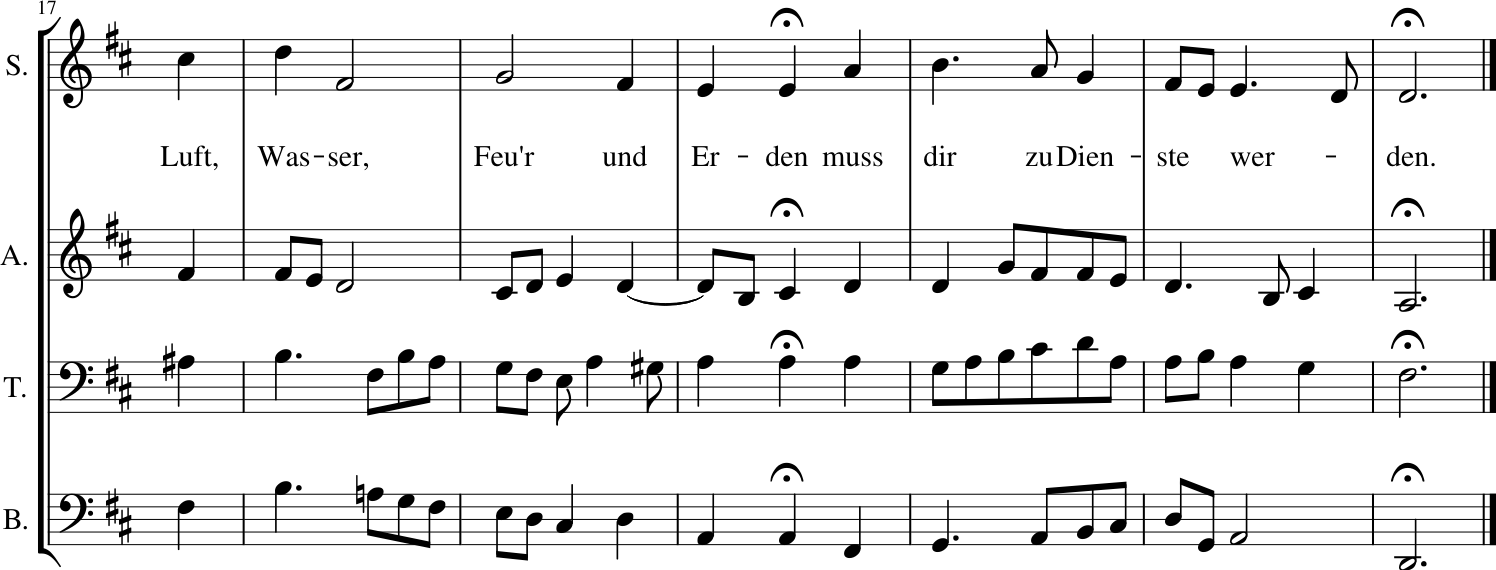

In [57]:
bach_34 = corpus.search(composer="Bach", timeSignature="3/4")
b = bach_34[0].parse()
b.show()

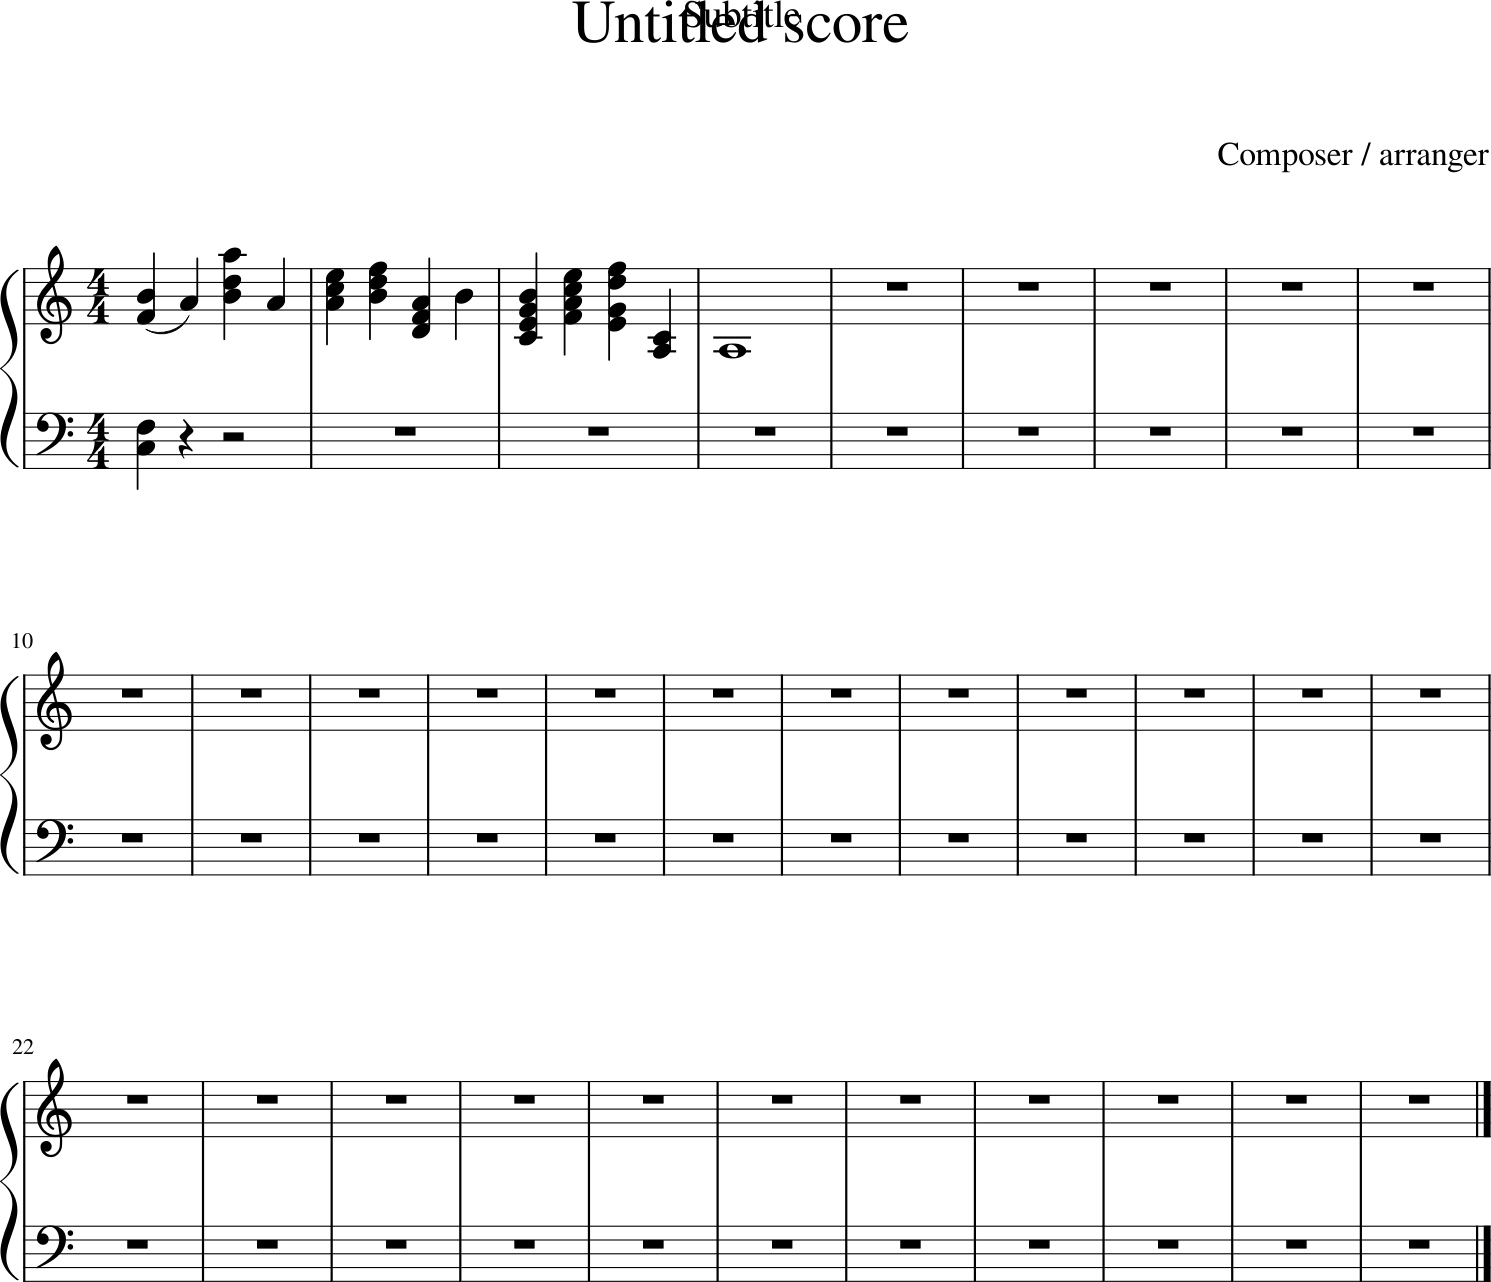

In [ ]:
p = converter.parse(f"{os.environ.get("ASSETS_ABSPATH")}/mxl/test.musicxml")
p.show()

/opt/conda/envs/music/lib/python3.13/site-packages/music21/musicxml/m21ToXml.py:531: MusicXMLWarning: <music21.stream.Score 0x7fa821e395b0> is not well-formed; see isWellFormedNotation()
  warnings.warn(f'{sc} is not well-formed; see isWellFormedNotation()',


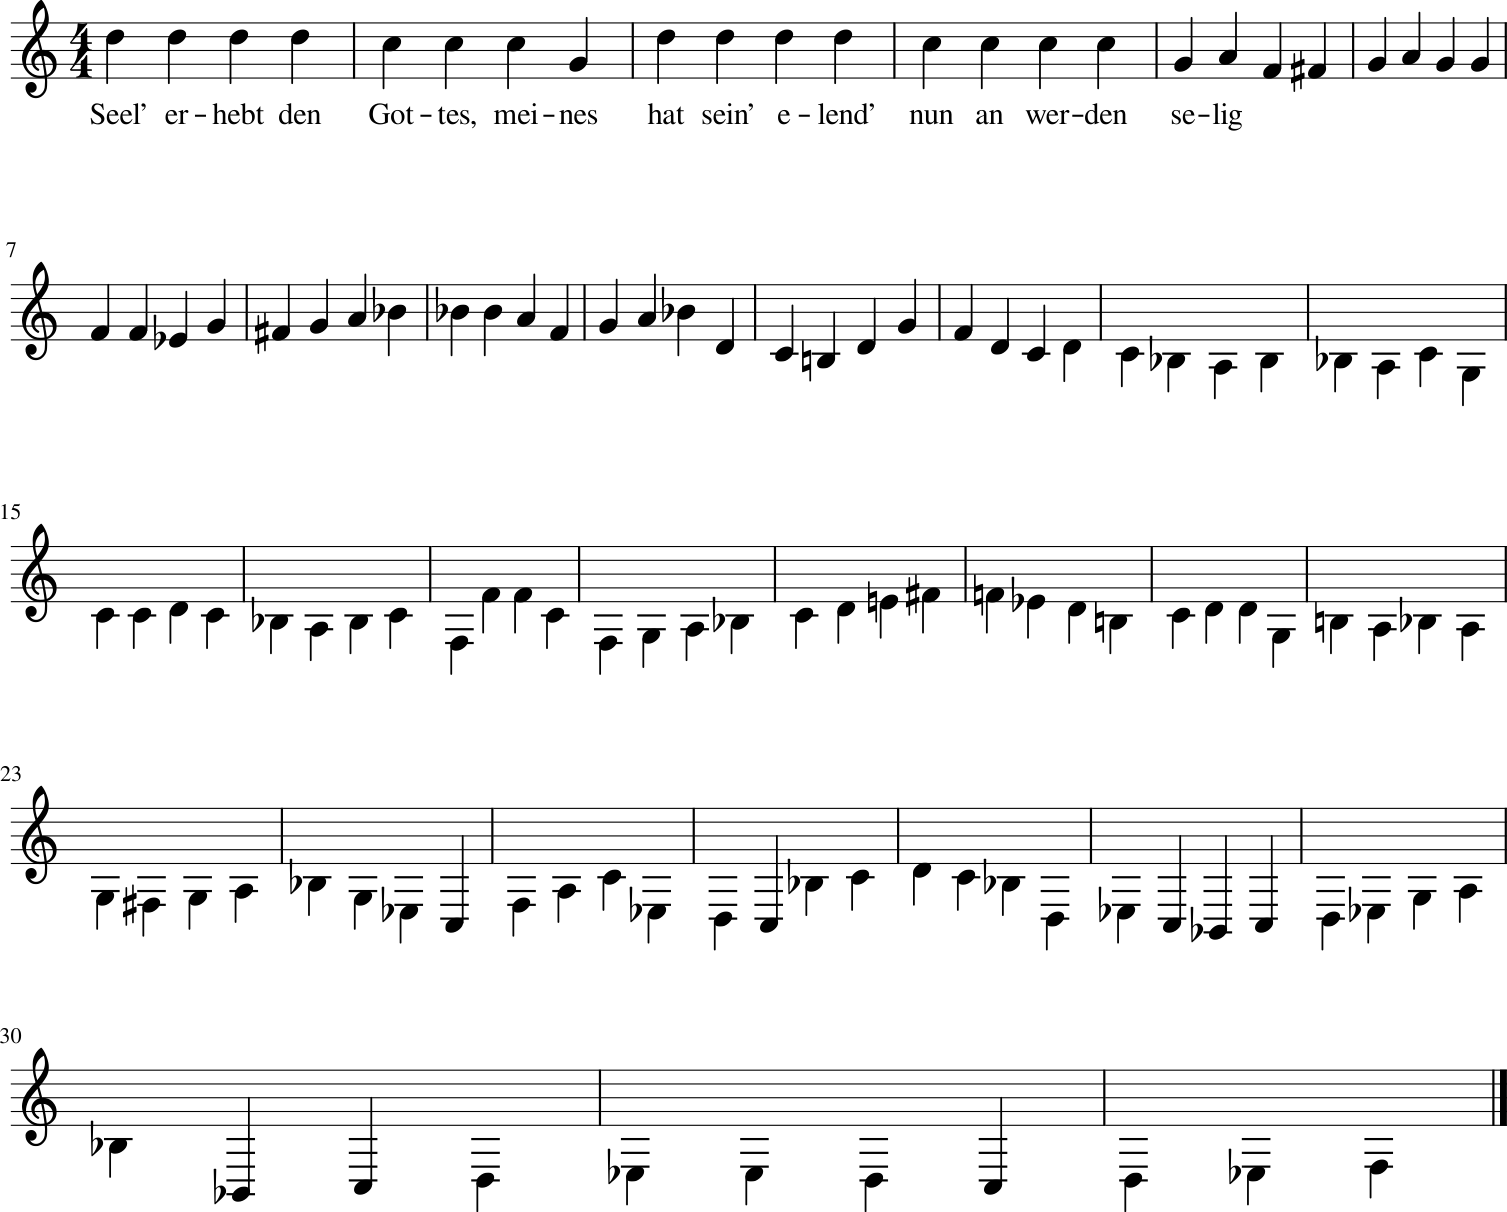

In [84]:
bach = corpus.search(composer="Bach")
s = bach[0].parse()

s2 = stream.Score()

for e in s.recurse().notes:
    if e.quarterLength == 1:
        s2.append(e)

s2.show()

/opt/conda/envs/music/lib/python3.13/site-packages/music21/musicxml/m21ToXml.py:531: MusicXMLWarning: <music21.stream.Score 0x7f4493cea2c0> is not well-formed; see isWellFormedNotation()
  warnings.warn(f'{sc} is not well-formed; see isWellFormedNotation()',


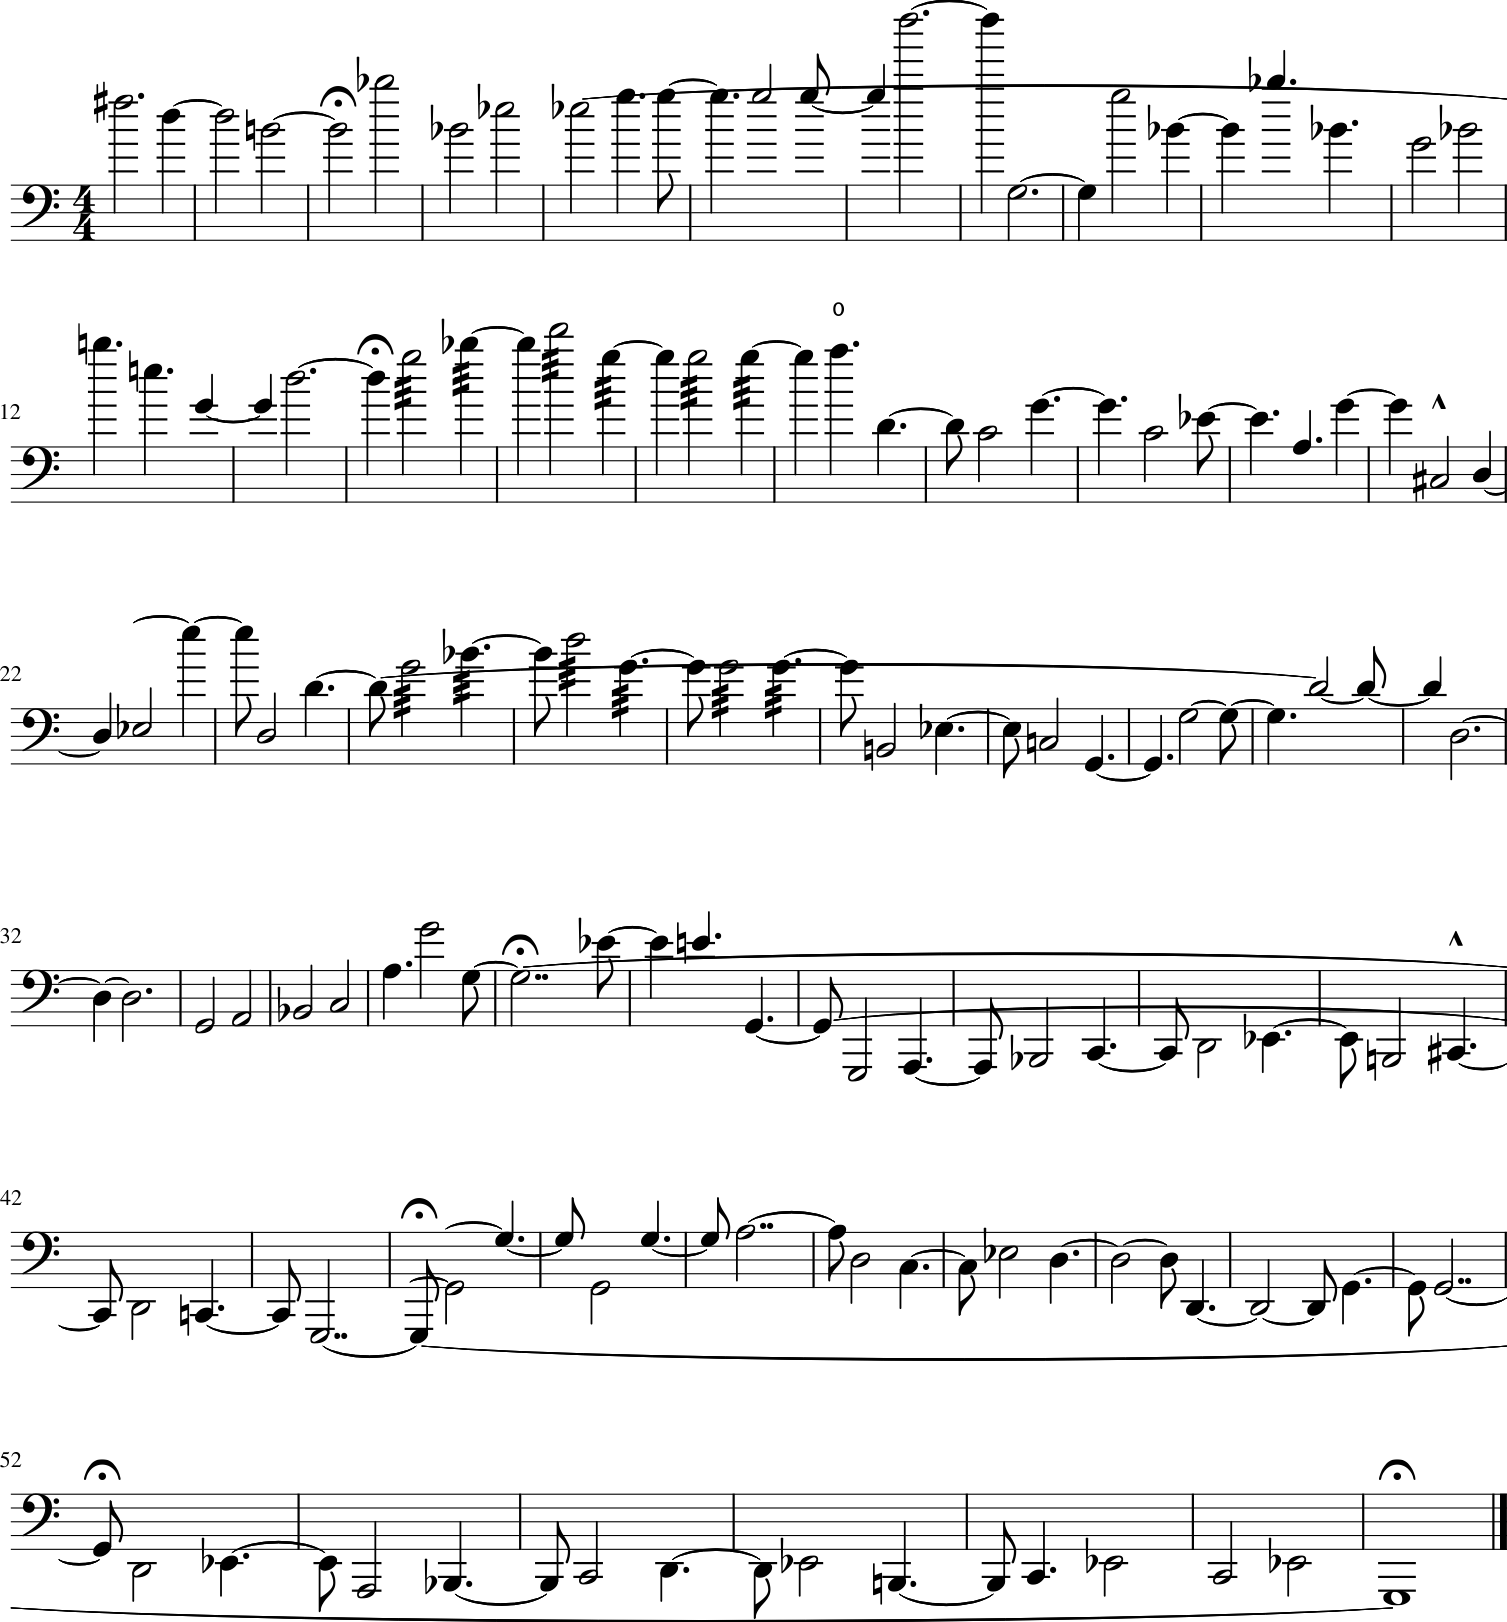

In [62]:
ASSETS_ABSPATH = pathlib.Path(os.environ.get("ASSETS_ABSPATH", "/assets"))
PIECE_ABSPATH = (
    ASSETS_ABSPATH
    / "MusicXML"
    / "Edward Elgar"
    / "Engima_Variations_String_Orchestra.mxl"
)

s = converter.parse(PIECE_ABSPATH)
t = stream.Score()
for e in s.recurse():
    if isinstance(e, note.Note):
        if e.quarterLength > 1:
            t.append(e)
t.show()

### Serial composition

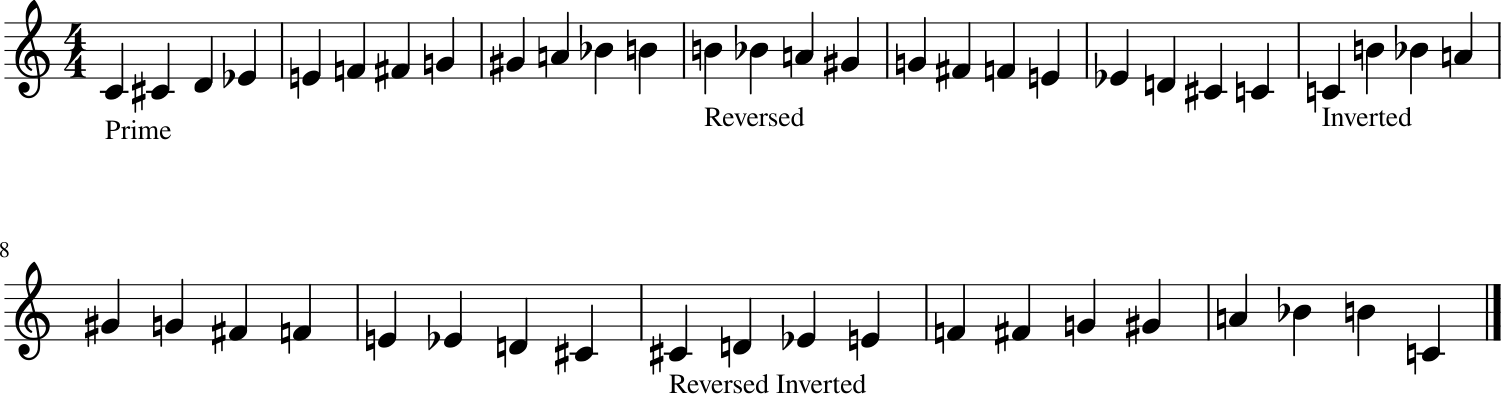

In [ ]:
# Prime forms
notes = "C G# C# G D B A F# E F E- B-".split(" ")
row1 = serial.ToneRow(notes)

row2 = {"prime": serial.ToneRow(list(range(0, 12)))}
row2["reversed"] = row2["prime"].zeroCenteredTransformation("R", 0)
row2["inverted"] = row2["prime"].zeroCenteredTransformation("I", 0)
row2["reversed_inverted"] = row2["prime"].zeroCenteredTransformation("RI", 0)

p = stream.Part()
for index, (key, values) in enumerate(row2.items()):
    label = expressions.TextExpression(" ".join(key.split("_")).title())
    p.append(label)
    p.append(values)

p.show()

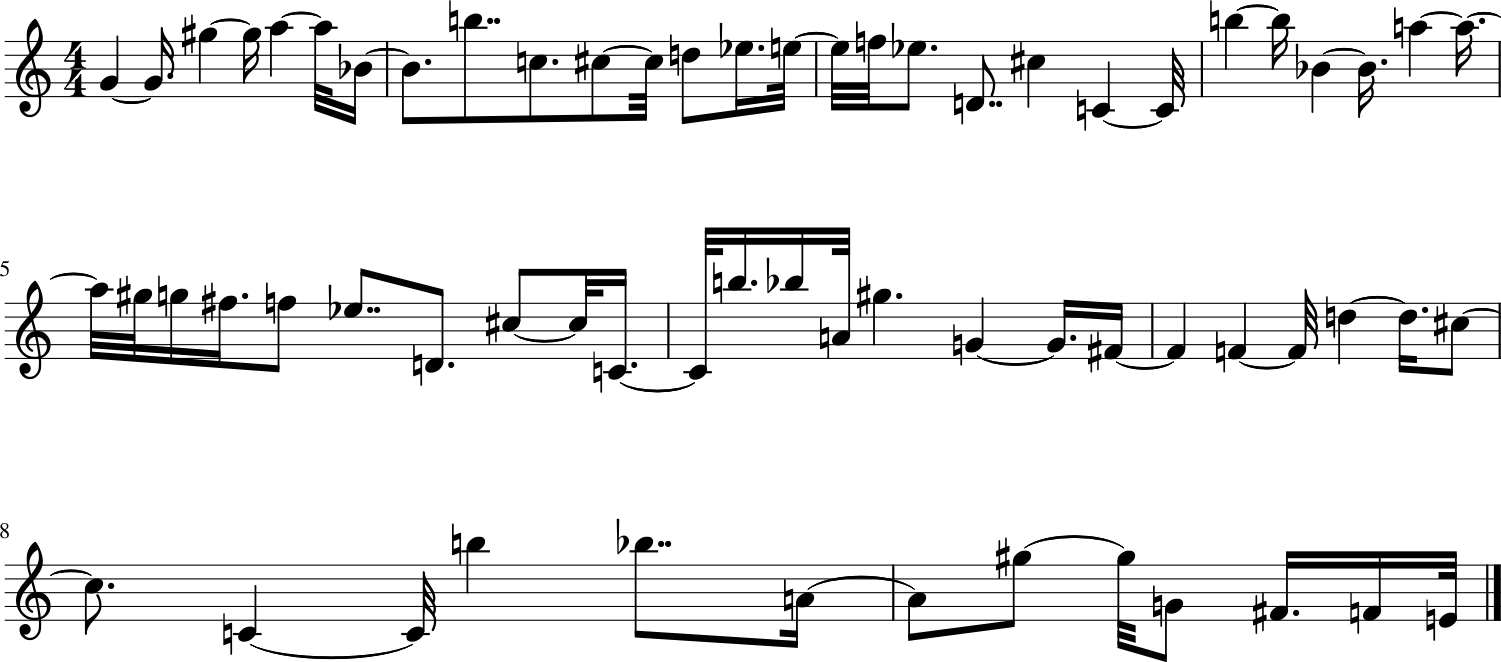

In [ ]:
def random_row_transformation(row: serial.ToneRow) -> serial.ToneRow:
    row_form = random.choice(["P", "R", "I", "RI"])
    row_index = random.randrange(0, 12)
    return row.zeroCenteredTransformation(row_form, row_index)


def serial_melody(
    row: serial.ToneRow, duration_unit: float, octave_range: tuple[int, int]
) -> stream.Stream:
    melody = stream.Stream()
    pitch_row = random_row_transformation(row)
    duration_row = random_row_transformation(row).pitchClasses()
    for i, pitch_class in enumerate(pitch_row):
        pitch_class.duration = duration.Duration(
            duration_unit * (duration_row[i] + 1)
        )
        pitch_class.octave = random.randint(*octave_range)
        melody.append(pitch_class)
    return melody


prime = serial.ToneRow(list(range(0, 11)))

s = stream.Score()
p = stream.Part()
for i in range(4):
    p.append(serial_melody(prime, 0.125, (4, 5)))
s.append(p)
s.show()

### Chords

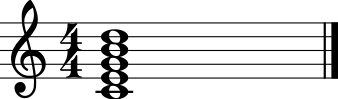

major-ninth chord
[11, 0, 2, 4, 7]
5-27A
[1, 2, 2, 2, 3, 0]
None


In [ ]:
c_min = chord.Chord("C4 E4 G4 B4 D5".split(" "))
c_min.transpose(2)
c_min.duration = duration.Duration(4)
c_min.show()
print(c_min.commonName)
print(c_min.normalOrder)
print(c_min.forteClass)
print(c_min.intervalVector)
print(c_min.getZRelation())

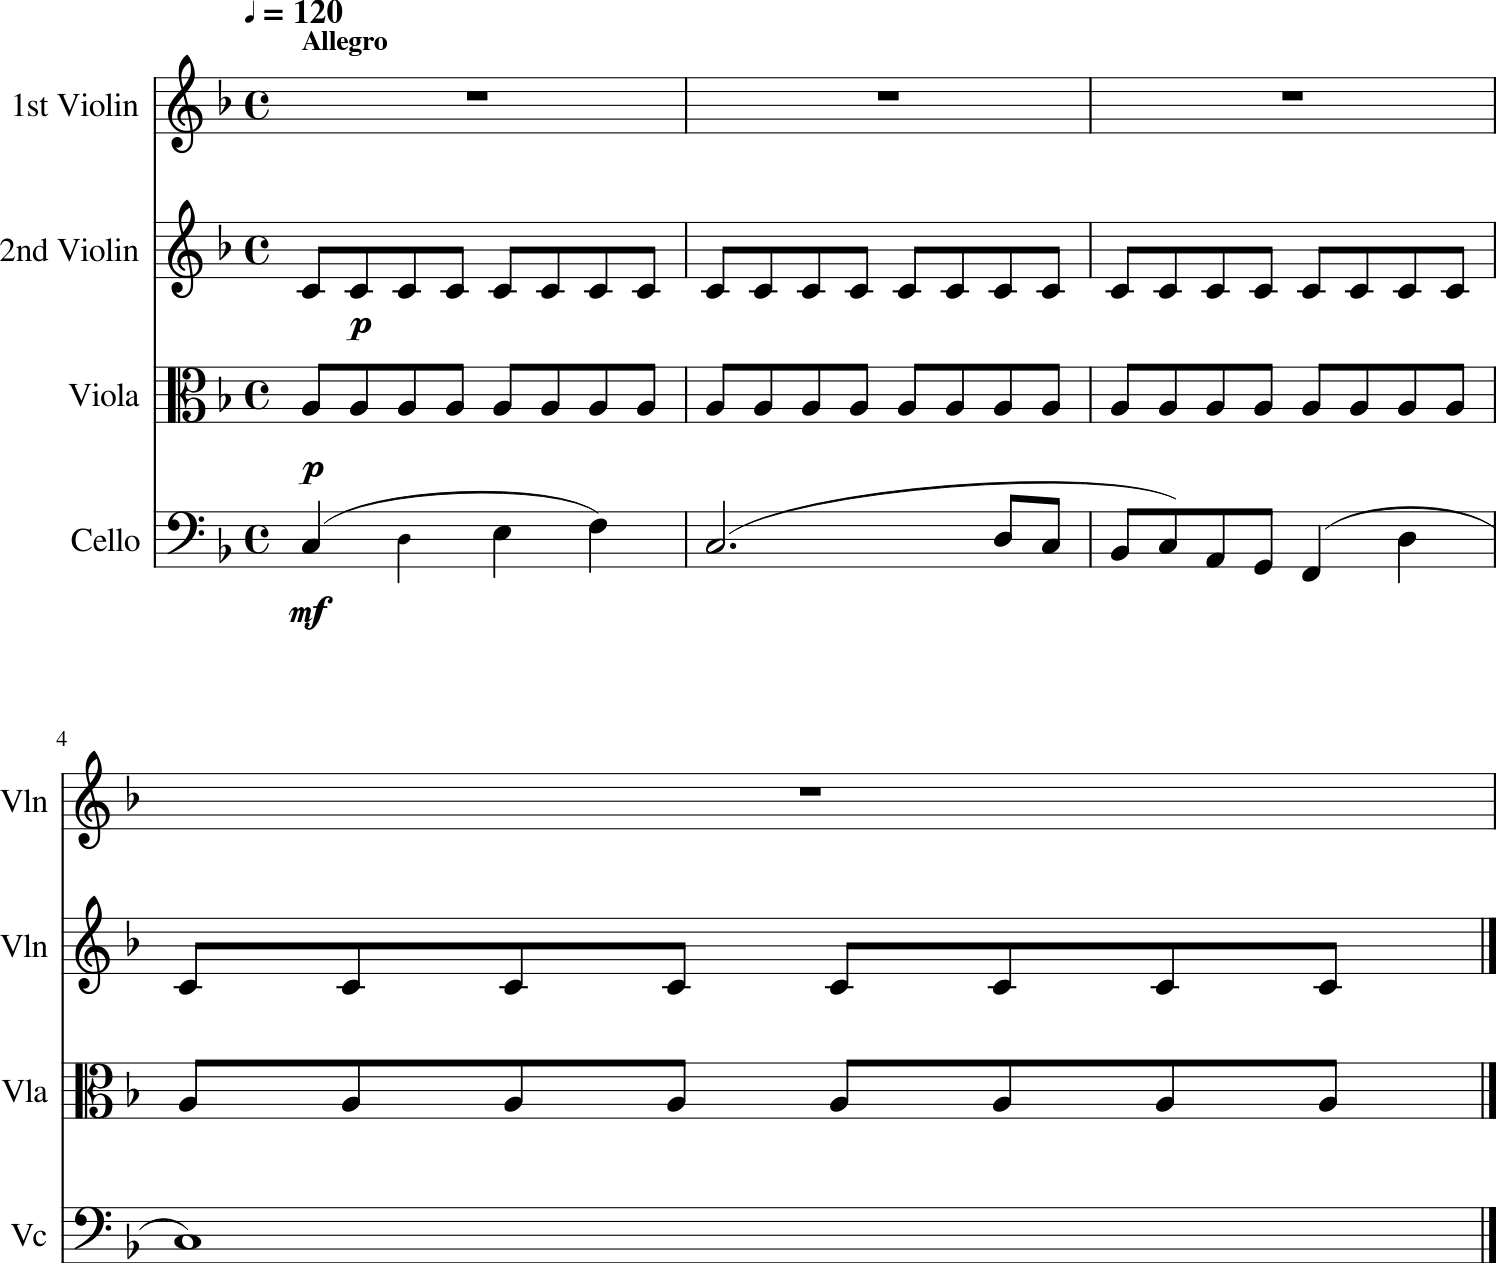

In [ ]:
# WARN couldn't get this to work
s = corpus.parse("beethoven/opus59no1/movement1.mxl")
head = stream.Score()
for p in s.parts:
    head.append(p.measures(0, 4))
# head.show()
head.chordify()
# print("Chordified")
head.show()

### Bach using tonerow

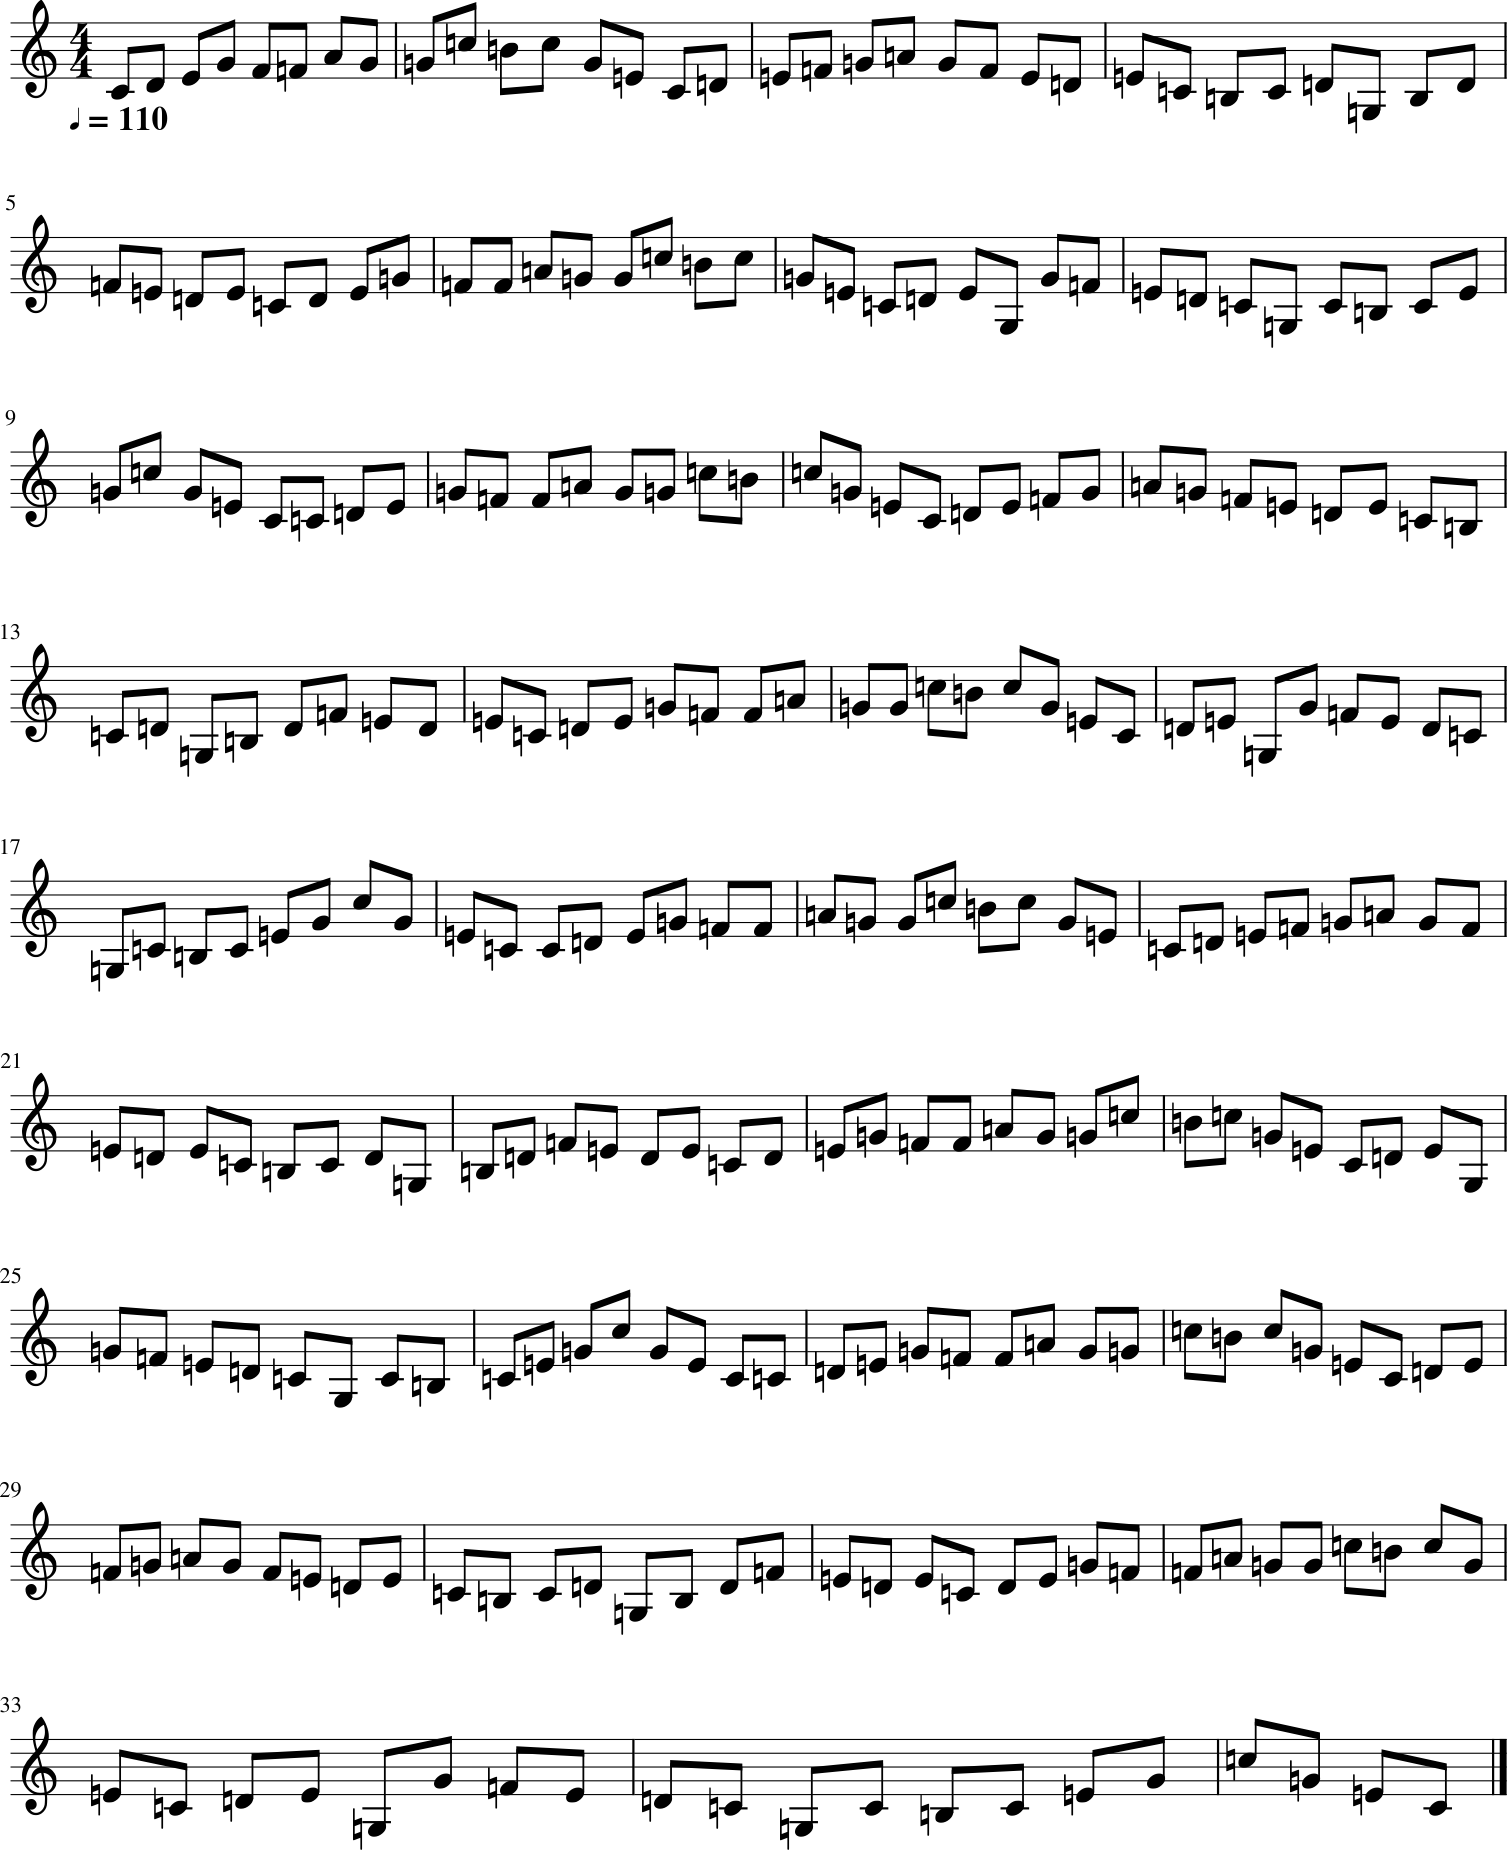

PosixPath('/utkusarioglu-com/workshops/signals-workshop/artifacts/bach.musicxml')

In [60]:
bach = [
    [
        0,
        2,
        4,
        7,
        5,
        5,
        9,
        7,
        7,
        12,
        11,
        12,
        7,
        4,
        0,
        2,
        4,
    ],
    [
        5,
        7,
        9,
        7,
        5,
        4,
        2,
        4,
        0,
        -1,
        0,
        2,
        -5,
        -1,
        2,
        5,
        4,
        2,
        4,
    ],
    [
        0,
        2,
        4,
        7,
        5,
        5,
        9,
        7,
        7,
        12,
        11,
        12,
        7,
        4,
    ],
    [
        0,
        2,
        4,
        -5,
        7,
        5,
        4,
        2,
        0,
        -5,
        0,
        -1,
        0,
        4,
        7,
        12,
        7,
        4,
    ],
    [0],
]

BASE = 60

s = stream.Score()
mm = tempo.MetronomeMark(number=110)
p = stream.Part()
p.insert(0, mm)
s.append(p)
for i in range(4):
    for pitch in itertools.chain.from_iterable(bach):
        p.append(note.Note(pitch + BASE, duration=duration.Duration(1 / 2)))
s.show()


ARTIFACTS_ABSPATH = pathlib.Path(os.environ.get("ARTIFACTS_ABSPATH", ""))
file_abspath = ARTIFACTS_ABSPATH / "bach.musicxml"
s.write("musicxml", fp=file_abspath)

### Stream to SuperCollider through OSC

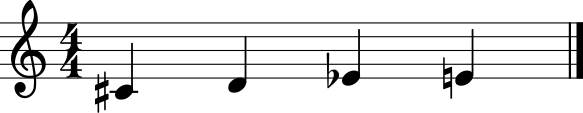

TypeError: 'Fraction' object cannot be interpreted as an integer

In [ ]:
t = serial.ToneRow([1, 2, 3, 4])
t.show()
client = SimpleUDPClient("192.168.1.151", 57121)
DECAY = 1 / 4
VOLUME = 90
first_tempo = (
    s.recurse().getElementsByClass(tempo.MetronomeMark).first().number
)
for n in s.recurse():
    if isinstance(n, note.Note):
        pitch = n.pitch.midi
        client.send_message("/piano", [0, pitch, VOLUME, DECAY])
        time.sleep(n.duration.quarterLength / first_tempo * 60)